# ConvNeXt 재학습 (회전 증강) — 회전 불변 분류기 만들기

## 목적
DOM 풀씬 평가에서 off-axis 방위각(60/120/300 등)은 90° 스냅 후에도 **30° 잔차**가 남고,
기존 분류기는 `RandomAffine(degrees=10)`으로 **±10°만** 배워서 이 잔차에 약하다.
→ 학습 증강을 **`RandomRotation(180°)`(전방위 회전)** 으로 바꿔 다시 학습하면
분류기가 **회전 불변**이 되어 off-axis를 살리면서 on-axis는 안 깎인다.
(추론 TTA가 평균 희석으로 무효였던 문제를 학습 단계에서 근본 해결.)

## 기존 convnext_soc50과의 유일한 차이
**train 증강에 `RandomRotation(180)` 추가**, 회전을 거기서 담당하므로 affine은 translate만.
데이터·모델·LR·에폭·손실·평가는 전부 동일 (공정 비교).

## 저장물 (기존 것과 안 겹침)
- `checkpoints/convnext_soc50_rot_final.pth` ← dom48 노트북에서 이 가중치로 교체
- `checkpoints/convnext_soc50_rot_ckpt.pth` (이어학습용)
- `results/convnext_soc50_rot.json`

## 사전 준비
- 드라이브 `MyDrive/ATRNet-STAR/soc50.tar`
- 런타임 → **T4 GPU** (ConvNeXt-Tiny 30에폭 ~45분; 끊겨도 재실행하면 이어서 학습)

## 1. GPU 확인 + 드라이브 마운트

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음 — 런타임 유형 변경!")

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU: Tesla T4
Mounted at /content/drive


## 2. 데이터 준비 (SOC-50 → 코랩 로컬)
드라이브 마운트에서 직접 읽으면 느려서 tar를 로컬에 해제. 이미 있으면 건너뜀.

In [ ]:
import os

SETTING  = "SOC_50classes"
TAR_PATH = f"{SAVE_DIR}/soc50.tar"
DATA_DIR = f"/content/{SETTING}"

if not os.path.exists(DATA_DIR):
    !cp "{TAR_PATH}" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

!ls "{DATA_DIR}"

test  train


## 3. 데이터셋 / 데이터로더 — 회전 증강이 핵심
- **train**: Resize128 → Grayscale3 → Flip → **RandomRotation(180)** → Affine(translate만) → ToTensor → RandomErasing
  - `RandomRotation(180)` = [-180°,180°] 전방위 회전 → 분류기를 회전 불변으로 학습
  - 회전을 RandomRotation이 담당하므로 affine은 `degrees=0`(이동만)
- **test**: 증강 없음 (Resize128 → Grayscale3 → ToTensor) — 기존과 동일
- 스케일은 train/test 동일(128) 유지 — 회전 모서리 검은영역은 표적이 중앙이라 영향 적음

In [ ]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

train_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),
    T.RandomRotation(180),                          # ★ 전방위 회전 (기존 대비 추가)
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # 회전은 위에서, 여기선 이동만
    T.ToTensor(),
    T.RandomErasing(p=0.3),
])
test_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

train_ds = ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds  = ImageFolder(TEST_DIR,  transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_ds.classes)
print(f"클래스 {NUM_CLASSES} / train {len(train_ds)} / test {len(test_ds)}")

클래스 50 / train 18071 / test 17603


## 4. 모델 — ConvNeXt-Tiny (ImageNet 사전학습)
기존 convnext_soc50과 동일: `classifier[2]`만 50클래스로 교체, label smoothing 0.1, AdamW 1e-4, cosine.

In [ ]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

MODEL_NAME = "convnext_soc50_rot"     # 파일명 (기존 convnext_soc50과 구분)
EPOCHS = 30
LR = 1e-4

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

os.makedirs(f"{SAVE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
CKPT_PATH = f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_ckpt.pth"
print(f"{MODEL_NAME} 파라미터: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 191MB/s]


convnext_soc50_rot 파라미터: 27.9M


## 5. 학습 루프 (체크포인트 이어학습)
에폭마다 드라이브에 체크포인트 저장 → 세션 끊겨도 재실행하면 이어서. 처음부터 다시 하려면
드라이브의 `convnext_soc50_rot_ckpt.pth` 삭제 후 실행.

In [ ]:
import time

start_epoch, history = 0, []
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch, history = ckpt["epoch"] + 1, ckpt["history"]
    print(f"체크포인트 발견 → 에폭 {start_epoch + 1}부터 재개")

t0 = time.time()
for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    scheduler.step()

    history.append({"epoch": epoch, "train_loss": total_loss/n, "train_acc": correct/n})
    print(f"Epoch {epoch+1}/{EPOCHS}  loss {total_loss/n:.3f}  train_acc {correct/n:.3f}  "
          f"({(time.time()-t0)/60:.1f}분 누적)")

    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "epoch": epoch, "history": history},
               CKPT_PATH)
print("학습 완료")

Epoch 1/30  loss 3.379  train_acc 0.145  (1.7분 누적)
Epoch 2/30  loss 2.748  train_acc 0.311  (3.5분 누적)
Epoch 3/30  loss 2.420  train_acc 0.420  (5.3분 누적)
Epoch 4/30  loss 2.202  train_acc 0.493  (7.1분 누적)
Epoch 5/30  loss 2.037  train_acc 0.550  (8.9분 누적)
Epoch 6/30  loss 1.905  train_acc 0.591  (10.7분 누적)
Epoch 7/30  loss 1.804  train_acc 0.625  (12.5분 누적)
Epoch 8/30  loss 1.722  train_acc 0.652  (14.2분 누적)
Epoch 9/30  loss 1.653  train_acc 0.673  (16.0분 누적)
Epoch 10/30  loss 1.578  train_acc 0.704  (17.7분 누적)
Epoch 11/30  loss 1.524  train_acc 0.722  (19.4분 누적)
Epoch 12/30  loss 1.487  train_acc 0.736  (21.1분 누적)
Epoch 13/30  loss 1.432  train_acc 0.753  (22.8분 누적)
Epoch 14/30  loss 1.397  train_acc 0.768  (24.5분 누적)
Epoch 15/30  loss 1.364  train_acc 0.781  (26.2분 누적)
Epoch 16/30  loss 1.328  train_acc 0.796  (27.9분 누적)
Epoch 17/30  loss 1.290  train_acc 0.810  (29.6분 누적)
Epoch 18/30  loss 1.274  train_acc 0.811  (31.3분 누적)
Epoch 19/30  loss 1.258  train_acc 0.819  (33.0분 누적)
Epoch 2

## 6. 평가 + 저장
SOC-50 test 정확도 측정 후 결과 json + 추론용 가중치 저장.
비교 기준: 기존 ConvNeXt(회전증강 없음) SOC-50 ≈ 81.6%. 회전 증강은 SOC가 살짝 낮아질 수 있으나
**DOM off-axis 강인성**을 얻는 트레이드오프 (dom48 노트북에서 진짜 효과 확인).

In [ ]:
import json
import numpy as np

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device, non_blocking=True))
        y_pred.extend(out.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

y_true, y_pred = np.array(y_true), np.array(y_pred)
overall_acc = float((y_true == y_pred).mean())
per_class_acc = {cls: float((y_pred[y_true == i] == i).mean())
                 for i, cls in enumerate(test_ds.classes) if (y_true == i).sum() > 0}

print(f"SOC-50 Overall Accuracy: {overall_acc*100:.2f}%   (기존 ConvNeXt 무회전 ≈ 81.6%)")

result = {"model": MODEL_NAME, "setting": "SOC-50", "epochs": EPOCHS, "lr": LR,
          "aug": "RandomRotation(180)", "overall_acc": overall_acc,
          "per_class_acc": per_class_acc, "classes": test_ds.classes,
          "y_true": y_true.tolist(), "y_pred": y_pred.tolist(), "history": history}
with open(f"{SAVE_DIR}/results/{MODEL_NAME}.json", "w") as f:
    json.dump(result, f)
torch.save(model.state_dict(), f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_final.pth")
print("저장:", f"results/{MODEL_NAME}.json", "+", f"checkpoints/{MODEL_NAME}_final.pth")

SOC-50 Overall Accuracy: 83.11%   (기존 ConvNeXt 무회전 ≈ 81.6%)
저장: results/convnext_soc50_rot.json + checkpoints/convnext_soc50_rot_final.pth


## 7. 학습 곡선

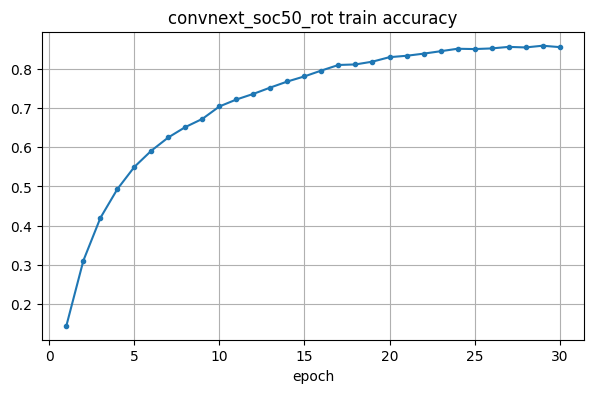

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot([h["epoch"]+1 for h in history], [h["train_acc"] for h in history], marker="o", ms=3)
plt.title(f"{MODEL_NAME} train accuracy"); plt.xlabel("epoch"); plt.grid(True); plt.show()

## 다음 단계 — dom48에서 효과 확인
`pipeline/soc50/dom48_convnext_rotaug.ipynb`의 분류기 로드 블록(셀 3)에서 가중치만 교체:
```python
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/convnext_soc50_rot_final.pth", map_location=device))
```
그리고 저장 CSV명을 `dom48_convnext_rot.csv`로 바꿔 재실행 → 기존 ConvNeXt(E2E 0.618)와 비교.
**기대: off-axis(60/120/300) cls 상승 + on-axis 유지 → 전체 E2E 상승.**